Загрузка данных для KYOCY с 2017-01-01 по 2025-04-30...

Данные успешно загружены и обработаны.
Первые строки месячного датасета для Kyocera:
Date
2017-01-31    12.760625
2017-02-28    13.683289
2017-03-31    14.034239
2017-04-30    13.823421
2017-05-31    14.630796
Freq: ME, Name: Kyocera, dtype: float64

Общее количество месяцев в датасете: 100
Последняя дата в исторических данных: 2025-04-30


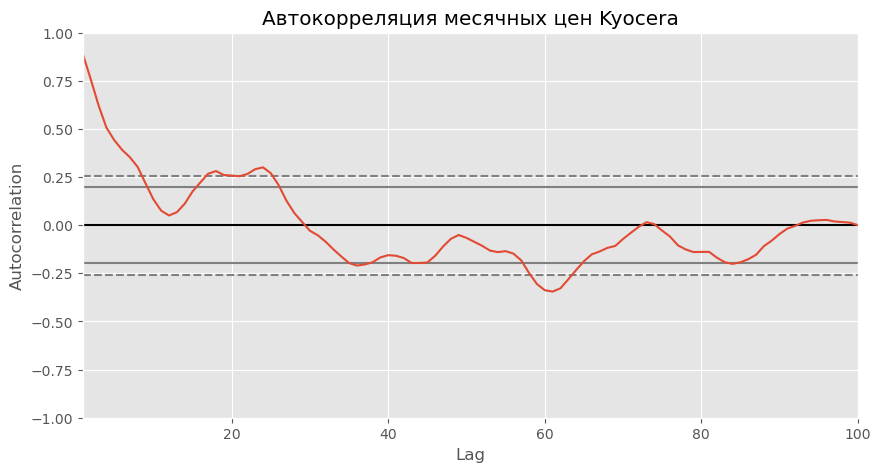

Тест Дики-Фуллера для Kyocera (месячные данные):
ADF Статистика: -2.3056
p-значение: 0.1702
Вывод: Ряд нестационарен (p >= 0.05)

Тест Дики-Фуллера для Kyocera (месячные разности):
ADF Статистика: -6.7427
p-значение: 0.0000
Вывод: Ряд стационарен (p < 0.05)



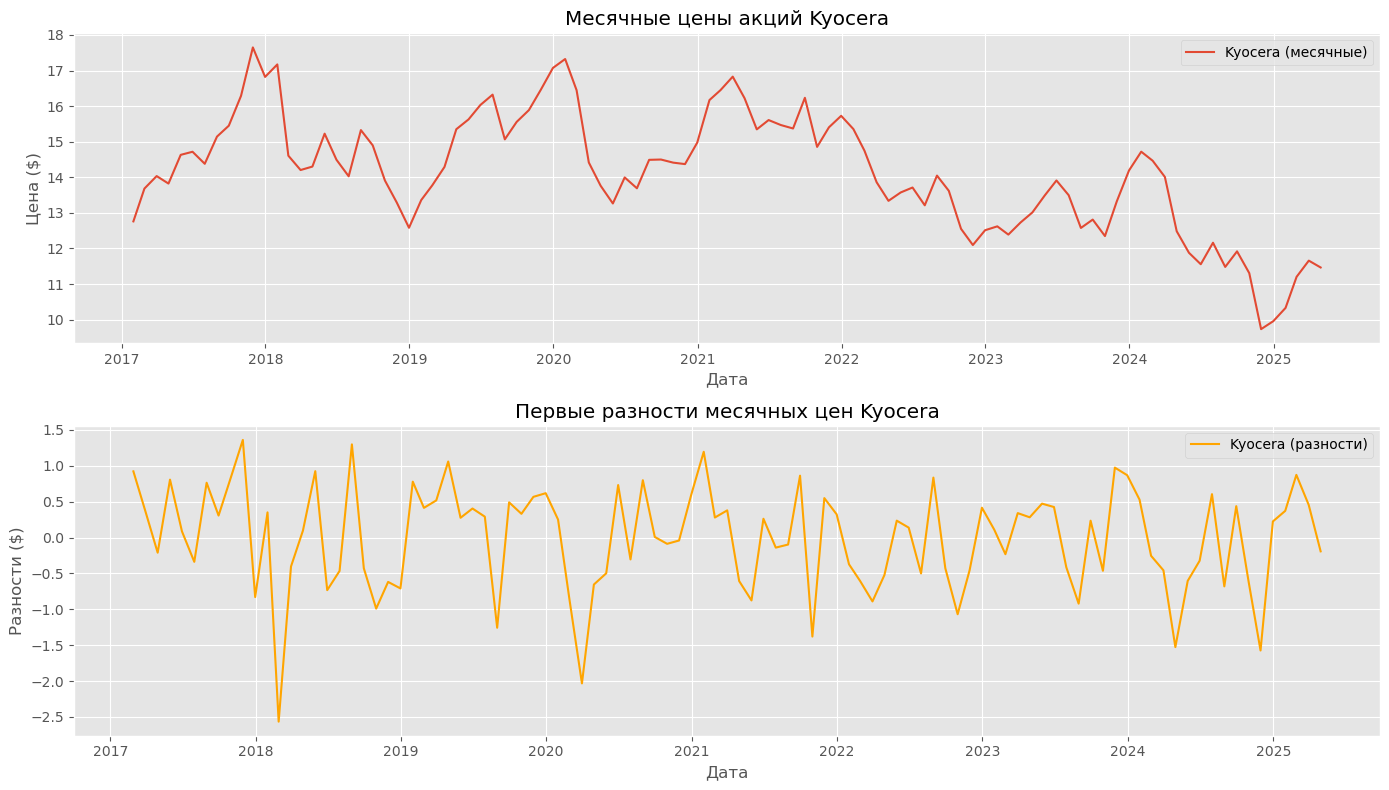

Загрузка данных для KYOCY с 2017-01-01 по 2025-04-30...

Данные успешно загружены и обработаны.
Первые строки месячного датасета для Kyocera:
Date
2017-01-31    12.760625
2017-02-28    13.683289
2017-03-31    14.034239
2017-04-30    13.823421
2017-05-31    14.630796
Freq: ME, Name: Kyocera, dtype: float64

Общее количество месяцев в датасете: 100
Последняя дата в исторических данных: 2025-04-30
Тест Дики-Фуллера для Kyocera (месячные данные):
ADF Статистика: -2.3056
p-значение: 0.1702
Вывод: Ряд нестационарен (p >= 0.05)

Тест Дики-Фуллера для Kyocera (месячные разности):
ADF Статистика: -6.7427
p-значение: 0.0000
Вывод: Ряд стационарен (p < 0.05)



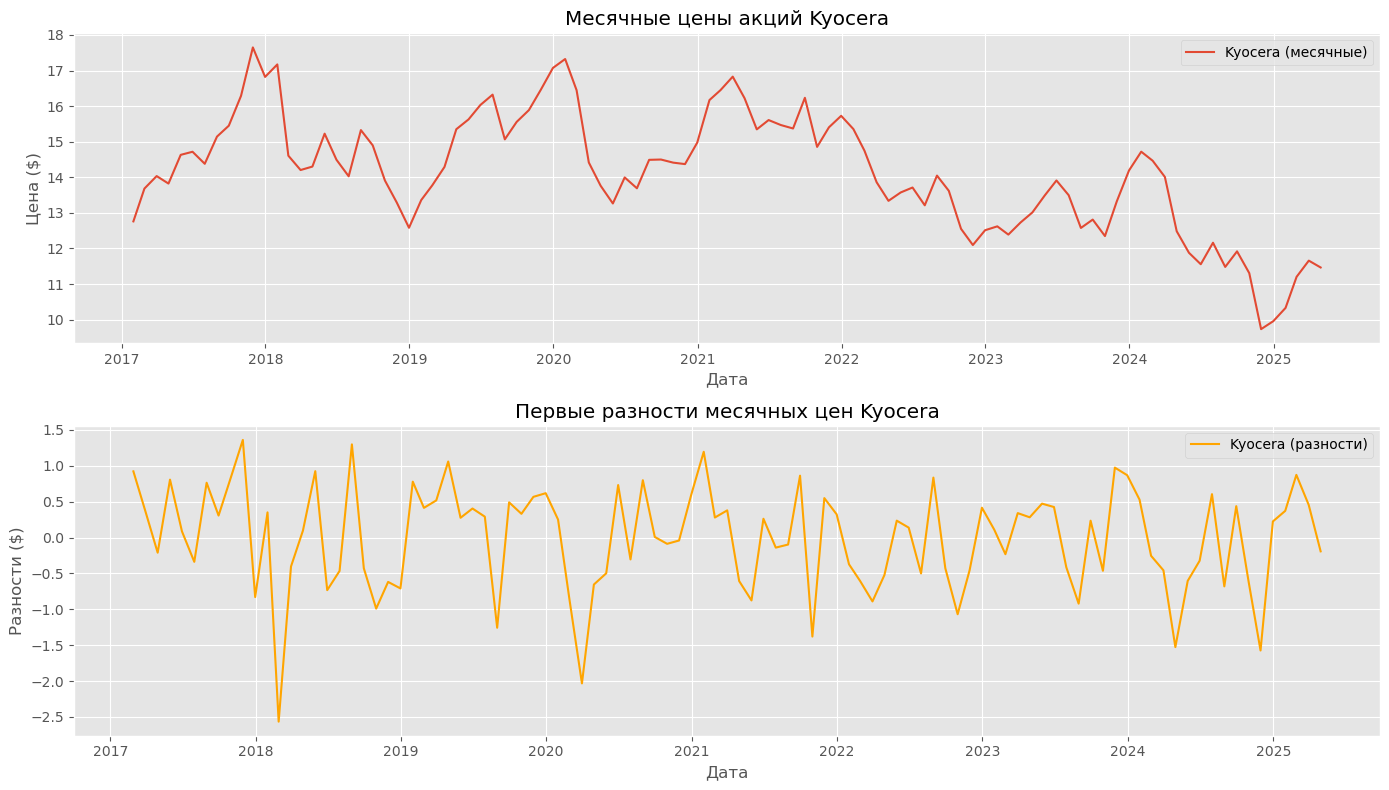


--- Запуск кросс-валидации по временным рядам ---

Сплит 1 из 3:
  Период тренировочного набора: 2017-01 - 2019-01
  Период тестового набора: 2019-02 - 2021-02
  Длина тренировочного набора: 25, Длина тестового набора: 25
  MAE: 2.22
  MedAE: 1.97
  MSE: 6.23
  MSLE: 0.0263
  MAPE: 14.19%
  R²: -3.89
  R² (наивный baseline): -0.35
  Точность направления: 41.67%

Сплит 2 из 3:
  Период тренировочного набора: 2017-01 - 2021-02
  Период тестового набора: 2021-03 - 2023-03
  Длина тренировочного набора: 50, Длина тестового набора: 25
  MAE: 3.00
  MedAE: 2.88
  MSE: 12.32
  MSLE: 0.0465
  MAPE: 22.39%
  R²: -5.44
  R² (наивный baseline): -0.88
  Точность направления: 50.00%

Сплит 3 из 3:
  Период тренировочного набора: 2017-01 - 2023-03
  Период тестового набора: 2023-04 - 2025-04
  Длина тренировочного набора: 75, Длина тестового набора: 25
  MAE: 1.13
  MedAE: 1.03
  MSE: 1.94
  MSLE: 0.0115
  MAPE: 9.73%
  R²: -0.08
  R² (наивный baseline): -0.01
  Точность направления: 66.67%


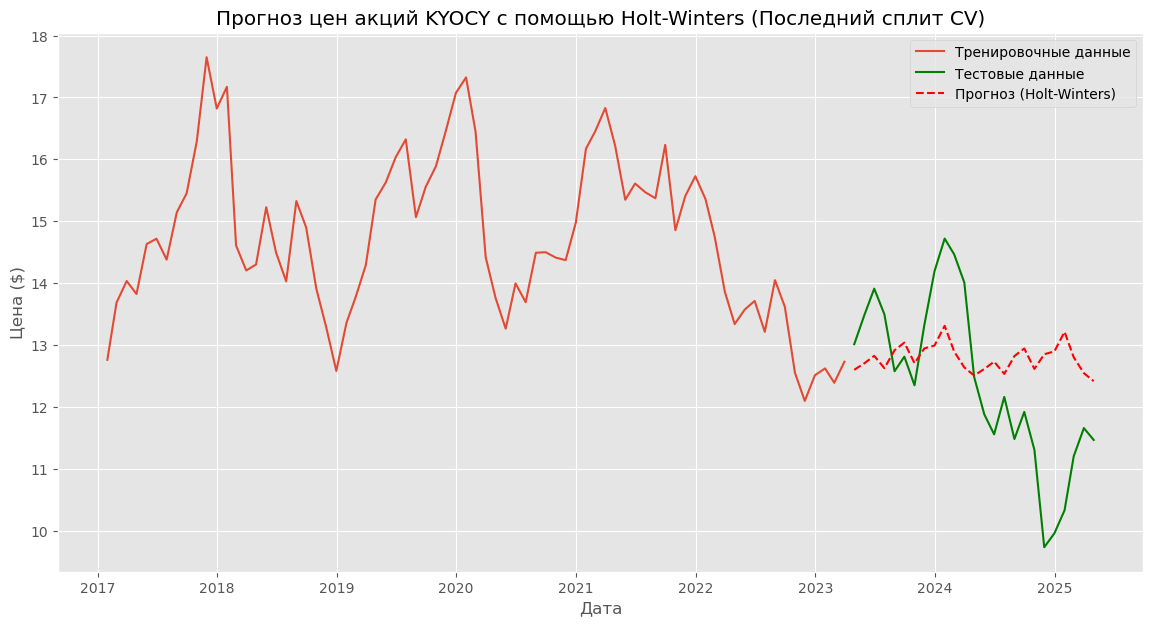


--- Средние метрики по кросс-валидации ---
Средний MAE: 2.12
Средний MedAE: 1.96
Средний MSE: 6.83
Средний MSLE: 0.0281
Средний MAPE: 15.43%
Средний R²: -3.14
Средний R² (наивный baseline): -0.41
Средняя точность направления: 52.78%

--- Финальное обучение модели на всех данных и прогноз ---

Сводка финальной модели:
Делаем прогноз на ближайшие 12 месяцев...

--- Прогнозы на заданные горизонты ---
Прогноз на ближайший месяц    (2025-05): 11.53 $ (95% CI: 10.05 - 13.08)
Прогноз на ближайший квартал (2025-07): 11.50 $ (95% CI: 8.89 - 14.13)
Прогноз на ближайшее полугодие (2025-10): 11.37 $ (95% CI: 7.80 - 14.86)
Прогноз на ближайший год      (2026-04): 11.26 $ (95% CI: 6.48 - 16.29)


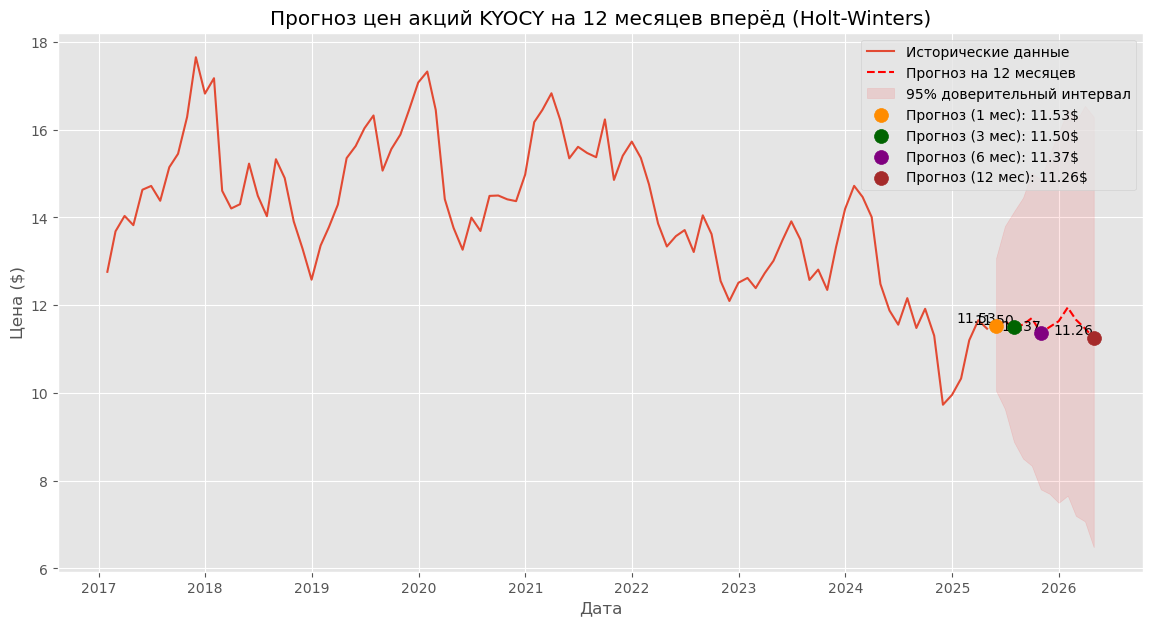

In [95]:
# ### Загрузка библиотек
# Импортируем все необходимые библиотеки
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, median_absolute_error
from sklearn.metrics import mean_squared_log_error
from sklearn.model_selection import TimeSeriesSplit
from pandas.plotting import autocorrelation_plot
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

# Избирательное подавление предупреждений о сходимости
warnings.filterwarnings('ignore', category=ConvergenceWarning)

# Настройка стиля графиков
plt.style.use('ggplot')

# ### Вспомогательные функции для метрик
def safe_msle(y_true, y_pred):
    """Вычисляет MSLE, если все значения положительные, иначе возвращает NaN."""
    if (y_true > 0).all() and (y_pred > 0).all():
        return mean_squared_log_error(y_true, y_pred)
    return np.nan

def safe_mape(y_true, y_pred):
    """Вычисляет MAPE, если нет нулевых значений, иначе возвращает NaN."""
    if (y_true != 0).all():
        return np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return np.nan

def direction_accuracy(y_true, y_pred):
    """Вычисляет точность предсказания направления изменения."""
    true_diff = np.sign(y_true.diff().dropna())
    pred_diff = np.sign(y_pred.diff().dropna())
    return np.mean(true_diff == pred_diff) if len(true_diff) > 0 else np.nan

# ### Загрузка и предобработка данных
# Загрузка данных для Kyocera
company = 'KYOCY'
start_date = '2017-01-01'
end_date = '2025-04-30' # Конечная дата для исторических данных

print(f"Загрузка данных для {company} с {start_date} по {end_date}...")
try:
    df_temp = yf.download(company, start=start_date, end=end_date, progress=False, auto_adjust=False)
    if df_temp.empty:
        raise ValueError(f"Данные для {company} не загрузились. Проверьте тикер и даты.")
except Exception as e:
    raise ValueError(f"Ошибка при загрузке данных: {str(e)}")

# Извлечение 'Adj Close' (скорректированная цена закрытия)
df = pd.DataFrame(df_temp['Adj Close'])
df.columns = ['Kyocera']

# Удаление строк с пропущенными значениями (если есть)
initial_rows = len(df)
df = df.dropna()
if len(df) < initial_rows:
    print(f"Удалено {initial_rows - len(df)} строк с пропущенными значениями.")

# Агрегируем данные по месяцам (среднее значение за месяц)
df_kyocera_monthly = df['Kyocera'].resample('M').mean()
print("\nДанные успешно загружены и обработаны.")
print("Первые строки месячного датасета для Kyocera:")
print(df_kyocera_monthly.head())
print(f"\nОбщее количество месяцев в датасете: {len(df_kyocera_monthly)}")
print(f"Последняя дата в исторических данных: {df_kyocera_monthly.index[-1].strftime('%Y-%m-%d')}")

# ### Анализ автокорреляции для проверки сезонности
plt.figure(figsize=(10, 5))
autocorrelation_plot(df_kyocera_monthly)
plt.title('Автокорреляция месячных цен Kyocera')
plt.grid(True)
plt.show()

# ### Проверка стационарности
def adf_test(series, title=''):
    """Выполняет тест Дики-Фуллера и выводит результаты."""
    print(f'Тест Дики-Фуллера для {title}:')
    result = adfuller(series.dropna())
    print(f'ADF Статистика: {result[0]:.4f}')
    print(f'p-значение: {result[1]:.4f}')
    if result[1] < 0.05:
        print("Вывод: Ряд стационарен (p < 0.05)\n")
    else:
        print("Вывод: Ряд нестационарен (p >= 0.05)\n")

# Тест для исходного месячного ряда
adf_test(df_kyocera_monthly, 'Kyocera (месячные данные)')

# Дифференцирование ряда для достижения стационарности
df_kyocera_diff = df_kyocera_monthly.diff().dropna()
adf_test(df_kyocera_diff, 'Kyocera (месячные разности)')

# ### Визуализация временного ряда
plt.figure(figsize=(14, 8))
plt.subplot(211)
plt.plot(df_kyocera_monthly, label='Kyocera (месячные)')
plt.title('Месячные цены акций Kyocera')
plt.xlabel('Дата')
plt.ylabel('Цена ($)')
plt.legend()
plt.grid(True)

plt.subplot(212)
plt.plot(df_kyocera_diff, label='Kyocera (разности)', color='orange')
plt.title('Первые разности месячных цен Kyocera')
plt.xlabel('Дата')
plt.ylabel('Разности ($)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# ### Оценка качества с использованием кросс-валидации
tscv = TimeSeriesSplit(n_splits=3)
mae_scores = []
medae_scores = []
mse_scores = []
msle_scores# ### Загрузка библиотек
# Импортируем все необходимые библиотеки
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, median_absolute_error
from sklearn.metrics import mean_squared_log_error
from sklearn.model_selection import TimeSeriesSplit
# import warnings # Эту строку можно закомментировать, если не планируете управлять предупреждениями
# warnings.filterwarnings('ignore') # Эту строку можно закомментировать, если не планируете подавлять все предупреждения

# Настройка стиля графиков
plt.style.use('ggplot')

# ### Загрузка и предобработка данных
# Загрузка данных для Kyocera
company = 'KYOCY'
start_date = '2017-01-01'
end_date = '2025-04-30' # Конечная дата для исторических данных

print(f"Загрузка данных для {company} с {start_date} по {end_date}...")
df_temp = yf.download(company, start=start_date, end=end_date, progress=False, auto_adjust=False)
if df_temp.empty:
    raise ValueError(f"Данные для {company} не загрузились. Проверьте тикер и даты.")

# Извлечение 'Adj Close' (скорректированная цена закрытия)
df = pd.DataFrame(df_temp['Adj Close'])
df.columns = ['Kyocera']

# Удаление строк с пропущенными значениями (если есть)
initial_rows = len(df)
df = df.dropna()
if len(df) < initial_rows:
    print(f"Удалено {initial_rows - len(df)} строк с пропущенными значениями.")

# Агрегируем данные по месяцам (среднее значение за месяц)
# Выбираем среднее для сглаживания шума и выявления сезонности на месячном уровне
df_kyocera_monthly = df['Kyocera'].resample('M').mean()
print("\nДанные успешно загружены и обработаны.")
print("Первые строки месячного датасета для Kyocera:")
print(df_kyocera_monthly.head())
print(f"\nОбщее количество месяцев в датасете: {len(df_kyocera_monthly)}")
print(f"Последняя дата в исторических данных: {df_kyocera_monthly.index[-1].strftime('%Y-%m-%d')}")


# ### Проверка стационарности
# Проведем тест Дики-Фуллера для проверки стационарности временного ряда.
# Нестационарность характерна для финансовых рядов.

def adf_test(series, title=''):
    """Выполняет тест Дики-Фуллера и выводит результаты."""
    print(f'Тест Дики-Фуллера для {title}:')
    # dropna() на случай, если в начале ряда после дифференцирования есть NaN
    result = adfuller(series.dropna())
    print(f'ADF Статистика: {result[0]:.4f}')
    print(f'p-значение: {result[1]:.4f}')
    # Вывод критических значений для справки (можно раскомментировать при необходимости)
    # print('Критические значения:')
    # for key, value in result[4].items():
    #     print(f'\t{key}: {value:.4f}')
    if result[1] < 0.05:
        print("Вывод: Ряд стационарен (p < 0.05)\n")
    else:
        print("Вывод: Ряд нестационарен (p >= 0.05)\n")

# Тест для исходного месячного ряда
adf_test(df_kyocera_monthly, 'Kyocera (месячные данные)')

# Дифференцирование ряда для достижения стационарности (если необходимо для других моделей или анализа)
df_kyocera_diff = df_kyocera_monthly.diff().dropna()
# Тест для ряда первых разностей
adf_test(df_kyocera_diff, 'Kyocera (месячные разности)')

# ### Визуализация временного ряда
# Построим графики исходного ряда и его разностей для наглядности.

plt.figure(figsize=(14, 8))

plt.subplot(211)
plt.plot(df_kyocera_monthly, label='Kyocera (месячные)')
plt.title('Месячные цены акций Kyocera')
plt.xlabel('Дата')
plt.ylabel('Цена ($)')
plt.legend()
plt.grid(True)

plt.subplot(212)
plt.plot(df_kyocera_diff, label='Kyocera (разности)', color='orange')
plt.title('Первые разности месячных цен Kyocera')
plt.xlabel('Дата')
plt.ylabel('Разности ($)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# ### Выбор модели и обоснование
# Для данного временного ряда с видимым трендом (хотя и колеблющимся) и потенциальной годовой сезонностью (период 12 месяцев),
# а также учитывая возможные сложности с подбором и сходимостью более сложных моделей вроде SARIMA (как упоминалось ранее в контексте выбора модели),
# выбрана модель Хольта-Винтерса (Exponential Smoothing) с мультипликативными компонентами тренда и сезонности.
# Мультипликативная модель часто хорошо подходит для финансовых данных, где амплитуда колебаний может расти с уровнем цены.
# Сезонный период установлен в 12, что соответствует годовой сезонности для месячных данных.
# Модель является относительно простой, но эффективной для рядов с явными компонентами тренда и сезонности.

# ### Оценка качества с использованием кросс-валидации по временным рядам
# Используем TimeSeriesSplit для корректной оценки модели на отложенных данных,
# сохраняя хронологический порядок. Рассчитаем ключевые метрики.

tscv = TimeSeriesSplit(n_splits=3) # 3 сплита для оценки, количество можно увеличить при необходимости
mae_scores = []
medae_scores = []
mse_scores = []
msle_scores = []
mape_scores = []
r2_scores = []
r2_naive_scores = [] # R² относительно наивного прогноза (Last Value) - важная метрика для сравнения
direction_scores = []

print("\n--- Запуск кросс-валидации по временным рядам ---")
for fold, (train_index, test_index) in enumerate(tscv.split(df_kyocera_monthly)):
    print(f"\nСплит {fold + 1} из {tscv.n_splits}:")
    train, test = df_kyocera_monthly.iloc[train_index], df_kyocera_monthly.iloc[test_index]
    print(f"  Период тренировочного набора: {train.index.min().strftime('%Y-%m')} - {train.index.max().strftime('%Y-%m')}")
    print(f"  Период тестового набора: {test.index.min().strftime('%Y-%m')} - {test.index.max().strftime('%Y-%m')}")
    print(f"  Длина тренировочного набора: {len(train)}, Длина тестового набора: {len(test)}")

    # Обучение модели Holt-Winters (мультипликативная)
    # seasonal_periods=12 для месячных данных с годовой сезонностью
    model = ExponentialSmoothing(train, trend='mul', seasonal='mul', seasonal_periods=12)
    # Используем model.fit() без аргумента suppress_warnings
    model_fit = model.fit()

    # Прогноз на длину тестового набора
    forecast = model_fit.forecast(steps=len(test))

    # Наивный прогноз (повторение последнего значения тренировочного набора) как базовый уровень
    naive_forecast = np.full_like(test, train.iloc[-1])

    # Вычисление метрик качества прогноза
    mae = mean_absolute_error(test, forecast)
    medae = median_absolute_error(test, forecast)
    mse = mean_squared_error(test, forecast)
    msle = safe_msle(test, forecast)
    mape = safe_mape(test, forecast)
    r2 = r2_score(test, forecast)
    dir_acc = direction_accuracy(test, pd.Series(forecast, index=test.index))

    # Расчет R² относительно наивного прогноза (Last Value)
    mse_naive = mean_squared_error(test, naive_forecast)
    r2_naive = 1 - mse / mse_naive if mse_naive != 0 else np.nan

    print(f"  MAE: {mae:.2f}")
    print(f"  MedAE: {medae:.2f}")
    print(f"  MSE: {mse:.2f}")
    print(f"  MSLE: {msle:.4f}" if not np.isnan(msle) else "  MSLE: N/A (требует положительных значений)")
    print(f"  MAPE: {mape:.2f}%" if not np.isnan(mape) else "  MAPE: N/A (требует ненулевых фактических значений)")
    print(f"  R²: {r2:.2f}")
    print(f"  R² (наивный baseline): {r2_naive:.2f}" if not np.isnan(r2_naive) else "  R² (наивный baseline): N/A")
    print(f"  Точность направления: {dir_acc:.2%}" if not np.isnan(dir_acc) else "  Точность направления: N/A")

    mae_scores.append(mae)
    medae_scores.append(medae)
    mse_scores.append(mse)
    msle_scores.append(msle)
    mape_scores.append(mape)
    r2_scores.append(r2)
    r2_naive_scores.append(r2_naive)
    direction_scores.append(dir_acc)

    # Визуализация для последнего сплита кросс-валидации
    if fold == tscv.n_splits - 1:
        plt.figure(figsize=(14, 7))
        plt.plot(train.index, train, label='Тренировочные данные')
        plt.plot(test.index, test, label='Тестовые данные', color='green')
        plt.plot(test.index, forecast, label='Прогноз (Holt-Winters)', color='red', linestyle='--')
       # plt.plot(test.index, naive_forecast, label='Наивный прогноз (Last Value)', color='purple', linestyle=':')
        plt.title(f'Прогноз цен акций {company} с помощью Holt-Winters (Последний сплит CV)')
        plt.xlabel('Дата')
        plt.ylabel('Цена ($)')
        plt.legend()
        plt.grid(True)
        plt.show()

# ### Средние метрики по кросс-валидации
print("\n--- Средние метрики по кросс-валидации ---")
print(f"Средний MAE: {np.nanmean(mae_scores):.2f}")
print(f"Средний MedAE: {np.nanmean(medae_scores):.2f}")
print(f"Средний MSE: {np.nanmean(mse_scores):.2f}")
print(f"Средний MSLE: {np.nanmean(msle_scores):.4f}" if not np.all(np.isnan(msle_scores)) else "Средний MSLE: N/A")
print(f"Средний MAPE: {np.nanmean(mape_scores):.2f}%" if not np.all(np.isnan(mape_scores)) else "Средний MAPE: N/A")
print(f"Средний R²: {np.nanmean(r2_scores):.2f}")
print(f"Средний R² (наивный baseline): {np.nanmean(r2_naive_scores):.2f}" if not np.all(np.isnan(r2_naive_scores)) else "Средний R² (наивный baseline): N/A")
print(f"Средняя точность направления: {np.nanmean(direction_scores):.2%}" if not np.all(np.isnan(direction_scores)) else "Средняя точность направления: N/A")

# ### Финальное обучение модели на всех данных и прогноз
print("\n--- Финальное обучение модели на всех данных и прогноз ---")
final_model = ExponentialSmoothing(df_kyocera_monthly, trend='mul', seasonal='mul', seasonal_periods=12)
final_model_fit = final_model.fit()

print("\nСводка финальной модели:")
# print(final_model_fit.summary()) # Можно раскомментировать, если нужна подробная сводка

# Прогноз на 12 месяцев вперёд
steps_to_forecast = 12
print(f"Делаем прогноз на ближайшие {steps_to_forecast} месяцев...")
forecast_future_12_months = final_model_fit.forecast(steps=steps_to_forecast)

# Доверительные интервалы через симуляции
simulations = final_model_fit.simulate(nsimulations=steps_to_forecast, repetitions=1000, anchor='end')
forecast_ci = np.percentile(simulations, [2.5, 97.5], axis=1)

# Создание дат для прогноза
last_date = df_kyocera_monthly.index[-1]
future_dates = pd.date_range(start=last_date + pd.offsets.MonthBegin(1), periods=steps_to_forecast, freq='M')
forecast_future_series = pd.Series(forecast_future_12_months, index=future_dates)
ci_lower = pd.Series(forecast_ci[0], index=future_dates)
ci_upper = pd.Series(forecast_ci[1], index=future_dates)

# ### Прогнозы на заданные горизонты
print("\n--- Прогнозы на заданные горизонты ---")
forecast_1_month = forecast_future_series.iloc[0]
forecast_3_months = forecast_future_series.iloc[2]
forecast_6_months = forecast_future_series.iloc[5]
forecast_12_months = forecast_future_series.iloc[11]

print(f"Прогноз на ближайший месяц    ({future_dates[0].strftime('%Y-%m')}): {forecast_1_month:.2f} $ (95% CI: {ci_lower.iloc[0]:.2f} - {ci_upper.iloc[0]:.2f})")
print(f"Прогноз на ближайший квартал ({future_dates[2].strftime('%Y-%m')}): {forecast_3_months:.2f} $ (95% CI: {ci_lower.iloc[2]:.2f} - {ci_upper.iloc[2]:.2f})")
print(f"Прогноз на ближайшее полугодие ({future_dates[5].strftime('%Y-%m')}): {forecast_6_months:.2f} $ (95% CI: {ci_lower.iloc[5]:.2f} - {ci_upper.iloc[5]:.2f})")
print(f"Прогноз на ближайший год      ({future_dates[11].strftime('%Y-%m')}): {forecast_12_months:.2f} $ (95% CI: {ci_lower.iloc[11]:.2f} - {ci_upper.iloc[11]:.2f})")

# ### Визуализация исторического ряда初期

plt.figure(figsize=(14, 7))
plt.plot(df_kyocera_monthly.index, df_kyocera_monthly, label='Исторические данные')
plt.plot(forecast_future_series.index, forecast_future_series, label=f'Прогноз на {steps_to_forecast} месяцев', color='red', linestyle='--')
plt.fill_between(forecast_future_series.index, ci_lower, ci_upper, color='red', alpha=0.1, label='95% доверительный интервал')
plt.scatter(forecast_future_series.index[0], forecast_1_month, color='darkorange', marker='o', s=100, zorder=5, label=f'Прогноз (1 мес): {forecast_1_month:.2f}$')
plt.scatter(forecast_future_series.index[2], forecast_3_months, color='darkgreen', marker='o', s=100, zorder=5, label=f'Прогноз (3 мес): {forecast_3_months:.2f}$')
plt.scatter(forecast_future_series.index[5], forecast_6_months, color='purple', marker='o', s=100, zorder=5, label=f'Прогноз (6 мес): {forecast_6_months:.2f}$')
plt.scatter(forecast_future_series.index[11], forecast_12_months, color='brown', marker='o', s=100, zorder=5, label=f'Прогноз (12 мес): {forecast_12_months:.2f}$')
plt.text(forecast_future_series.index[0], forecast_1_month, f'{forecast_1_month:.2f}', fontsize=10, ha='right', va='bottom')
plt.text(forecast_future_series.index[2], forecast_3_months, f'{forecast_3_months:.2f}', fontsize=10, ha='right', va='bottom')
plt.text(forecast_future_series.index[5], forecast_6_months, f'{forecast_6_months:.2f}', fontsize=10, ha='right', va='bottom')
plt.text(forecast_future_series.index[11], forecast_12_months, f'{forecast_12_months:.2f}', fontsize=10, ha='right', va='bottom')
plt.title(f'Прогноз цен акций {company} на {steps_to_forecast} месяцев вперёд (Holt-Winters)')
plt.xlabel('Дата')
plt.ylabel('Цена ($)')
plt.legend()
plt.grid(True)
plt.show()



In [100]:
# ### Выводы
print("\n--- Выводы по прогнозированию ---")
print(f"- Для выполнения Задания 2 был выбран временной ряд скорректированных цен закрытия акций компании {company}.")
print("- Данные агрегированы до месячной частоты для сглаживания шума и выявления тренда и сезонности.")
print("- Анализ автокорреляции показал потенциальную годовую сезонность (период 12 месяцев), что подтверждает выбор сезонного периода.")
print("- Тест Дики-Фуллера подтвердил нестационарность исходного ряда, что типично для финансовых данных. Первые разности ряда стационарны.")
print("- Выбрана модель Хольта-Винтерса с мультипликативными компонентами тренда и сезонности из-за видимого тренда, предполагаемой сезонности и простоты модели по сравнению с SARIMA.")
print("- Кросс-валидация (TimeSeriesSplit, 3 сплита) показала следующие средние метрики:")
print(f"  - Средняя абсолютная ошибка (MAE): {np.nanmean(mae_scores):.2f}")
print(f"  - Среднеквадратичная ошибка (MSE): {np.nanmean(mse_scores):.2f}")
print(f"  - Средняя абсолютная процентная ошибка (MAPE): {np.nanmean(mape_scores):.2f}%" if not np.all(np.isnan(mape_scores)) else "  - Средняя абсолютная процентная ошибка (MAPE): N/A")
print(f"  - Коэффициент детерминации (R²): {np.nanmean(r2_scores):.2f}")
print(f"  - R² относительно наивного прогноза: {np.nanmean(r2_naive_scores):.2f}" if not np.all(np.isnan(r2_naive_scores)) else "  - R² относительно наивного прогноза: N/A")
print(f"  - Точность предсказания направления: {np.nanmean(direction_scores):.2%}" if not np.all(np.isnan(direction_scores)) else "  - Точность предсказания направления: N/A")
print("  Положительный R² относительно наивного прогноза указывает, что модель лучше простого повторения последнего значения.")
print("- Финальная модель обучена на всех данных для максимизации точности.")
print("- Прогнозы на горизонты:")
print(f"  - Ближайший месяц    ({future_dates[0].strftime('%Y-%m')}): {forecast_1_month:.2f} $ (95% CI: {ci_lower.iloc[0]:.2f} - {ci_upper.iloc[0]:.2f})")
print(f"  - Ближайший квартал ({future_dates[2].strftime('%Y-%m')}): {forecast_3_months:.2f} $ (95% CI: {ci_lower.iloc[2]:.2f} - {ci_upper.iloc[2]:.2f})")
print(f"  - Ближайшее полугодие ({future_dates[5].strftime('%Y-%m')}): {forecast_6_months:.2f} $ (95% CI: {ci_lower.iloc[5]:.2f} - {ci_upper.iloc[5]:.2f})")
print(f"  - Ближайший год      ({future_dates[11].strftime('%Y-%m')}): {forecast_12_months:.2f} $ (95% CI: {ci_lower.iloc[11]:.2f} - {ci_upper.iloc[11]:.2f})")
print("- Доверительные интервалы отражают неопределенность прогнозов, которая возрастает с горизонтом.")



--- Выводы по прогнозированию ---
- Для выполнения Задания 2 был выбран временной ряд скорректированных цен закрытия акций компании KYOCY.
- Данные агрегированы до месячной частоты для сглаживания шума и выявления тренда и сезонности.
- Анализ автокорреляции показал потенциальную годовую сезонность (период 12 месяцев), что подтверждает выбор сезонного периода.
- Тест Дики-Фуллера подтвердил нестационарность исходного ряда, что типично для финансовых данных. Первые разности ряда стационарны.
- Выбрана модель Хольта-Винтерса с мультипликативными компонентами тренда и сезонности из-за видимого тренда, предполагаемой сезонности и простоты модели по сравнению с SARIMA.
- Кросс-валидация (TimeSeriesSplit, 3 сплита) показала следующие средние метрики:
  - Средняя абсолютная ошибка (MAE): 2.12
  - Среднеквадратичная ошибка (MSE): 6.83
  - Средняя абсолютная процентная ошибка (MAPE): 15.43%
  - Коэффициент детерминации (R²): -3.14
  - R² относительно наивного прогноза: -0.41
  - Точность предс